# Currency style premia for a euro-based investor: carry, momentum and value

**Business question.** A euro-based multi-asset fund considers a currency overlay that harvests the three classic FX style
premia in the G10 currencies: **carry** (long high-yielding, short low-yielding currencies), **momentum** (long recent
winners, short losers) and **value** (long currencies that have become cheap). The investment committee asks:

1. Is there a premium, after costs, against the euro, and did it survive after 2012?
2. What does it cost in crash risk, and can simple risk management (volatility scaling, a VIX filter) reduce it?
3. Does a risk-balanced combination of the three styles meet the criteria fixed in advance, once the number of
   configurations tried is taken into account?

**Data.** ECB euro reference rates for nine G10 currencies (daily since January 1999, sampled at month ends) and OECD
3-month interbank rates from FRED. The VIX (CBOE, via FRED) is used for the crash-risk analysis. Returns are monthly
log excess returns of forward-like positions: interest differential plus spot change.

**Rules and timing.** Signals use information up to the end of month $t$ and portfolios are traded at that month-end and
held over month $t+1$. Every portfolio is euro-neutral: long the 3 currencies with the highest signal and short the 3 lowest,
1/3 each. Costs are 3 bp per unit of turnover (entries included). The primary configuration of each style is taken from the
literature before looking at the data; the other 51 configurations of the robustness grid count as trials in the
overfitting diagnostics. In-sample 1999-2012, out-of-sample 2013-2025, as in the other notebooks of the repository.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "backtest_engine").is_dir())
try:
    import backtest_engine
except ImportError:  # not installed: use the source folder (the extension must be built in place)
    sys.path.insert(0, str(ROOT / "scripts" / "backtest_engine"))
    import backtest_engine
from backtest_engine import data, fx_factors as fx, metrics as mt, strategies as st

core = backtest_engine.require_cpp()

DATA_MODE = os.environ.get("BACKTEST_ENGINE_DATA_MODE", "official")  # "official" (ECB, OECD via FRED) or "synthetic"
START, END = "1999-01-01", "2025-12-31"
CURRENCIES = fx.G10                  # USD, JPY, GBP, CHF, SEK, NOK, CAD, AUD, NZD (DKK excluded: pegged to the euro)
IS_END, OOS_START = "2012-12-31", "2013-01-01"   # same split as the other notebooks of the repository
N_SIDE, SCHEME = 3, "equal"          # long 3, short 3, equal weights (the standard G10 construction)
MOM_LOOKBACK, MOM_SKIP = 12, 1       # 12-month momentum skipping the last month (Asness, Moskowitz and Pedersen, 2013)
VALUE_HORIZON = 60                   # 5-year reversal (value proxy)
COST_BP = 3.0                        # cost per unit of turnover, bp: about the G10 half spread plus fees
VOL_WINDOW, TARGET_VOL = 36, 0.10    # trailing window (months) and target of the risk-balanced combination
VIX_THRESHOLD = 25.0                 # risk-off filter: no carry position when the VIX closes a month above this level
NW_LAGS = 6
SEED = 20240517
OUTPUT_DIR = ROOT / "outputs" / "fx_factors"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Decision criteria agreed before looking at the results (the committee's policy, not fitted values).
CRITERIA = {
    "Sharpe ratio 2013-2025 (net)": (">=", 0.50),
    "Bootstrap 95% lower bound of the 2013-2025 Sharpe ratio": (">", 0.0),
    "Deflated Sharpe ratio (all configurations tried)": (">=", 0.95),
    "Maximum drawdown 2013-2025": (">=", -0.20),
    "Break-even cost / assumed cost": (">=", 3.0),
}

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
from backtest_engine.figstyle import MUTED, NEGATIVE, SERIES, notebook_style, ordinal_colors
notebook_style()   # validated palette, recessive grid, constrained layout (see figstyle.py)
print(f"backtest_engine {backtest_engine.__version__} | data mode: {DATA_MODE}")

backtest_engine 0.1.0 | data mode: official


## 1. Data and the forward premium puzzle

Monthly excess return of a long position in currency $c$ funded in euros:
$rx_{c,t+1} = \ln(1 + i_{c,t}/1200) - \ln(1 + i_{EUR,t}/1200) + \Delta \ln S_{c,t+1}$, with $S$ in euros per unit of
currency. Carry pays only if high-rate currencies do not depreciate by their interest differential. Uncovered interest parity
(UIP) says they do. The Fama regression of $\Delta \ln S_{t+1}$ on $(i_{EUR} - i_c)_t$ has slope $\beta = 1$ under UIP.

In [2]:
panel = fx.load_fx_panel(CURRENCIES, START, END, official=DATA_MODE == "official")
spot, rates = panel["spot"], panel["rates"]
rx = fx.excess_returns(spot, rates)
print("Source:", panel["source"])
print(f"{len(rx)} monthly excess returns from {rx.index[0]:%B %Y} to {rx.index[-1]:%B %Y}")
diff = fx.carry_signal(rates, CURRENCIES)
table = pd.DataFrame({"interest differential vs EUR (% p.a.)": diff.mean(),
                      "spot change (% p.a.)": 1200 * np.log(spot).diff().mean(),
                      "excess return (% p.a.)": 1200 * rx.mean(), "volatility (% p.a.)": 100 * np.sqrt(12) * rx.std()})
display(table.sort_values("interest differential vs EUR (% p.a.)"))
uip = fx.uip_regressions(spot, rates, lags=NW_LAGS)
display(uip)
b = uip.loc["pooled (currency intercepts)"]
print(f"pooled UIP slope {b['beta']:.2f} (s.e. {b['NW s.e.']:.2f}): 95% interval "
      f"{b['beta'] - 1.96 * b['NW s.e.']:.2f} to {b['beta'] + 1.96 * b['NW s.e.']:.2f}")

Source: ECB euro reference rates; OECD 3-month interbank rates via FRED (call money rate for Japan before April 2002)
323 monthly excess returns from February 1999 to December 2025


,interest differential vs EUR (% p.a.),spot change (% p.a.),excess return (% p.a.),volatility (% p.a.)
JPY,-1.460,-1.233,-2.692,10.931
CHF,-1.204,2.039,0.843,5.708
SEK,-0.055,-0.735,-0.789,5.784
CAD,0.501,0.261,0.763,8.611
USD,0.632,-0.118,0.510,9.321
GBP,1.081,-0.867,0.209,7.263
NOK,1.511,-1.198,0.308,7.661
AUD,2.103,0.105,2.205,8.758
NZD,2.457,0.130,2.587,9.312


,beta,NW s.e.,t (beta = 1),R2,months
USD,-0.877,1.536,-1.221,0.001,323.000
JPY,0.594,1.484,-0.274,0.001,323.000
GBP,0.324,1.442,-0.469,0.000,323.000
CHF,-1.454,1.458,-1.683,0.003,317.000
SEK,-1.257,2.302,-0.981,0.001,323.000
NOK,0.807,1.317,-0.146,0.001,323.000
CAD,-0.322,1.625,-0.814,0.000,323.000
AUD,-0.502,1.324,-1.135,0.000,323.000
NZD,2.645,1.725,0.954,0.008,323.000
pooled (currency intercepts),0.198,0.705,-1.138,0.000,"2,901.000"


pooled UIP slope 0.20 (s.e. 0.71): 95% interval -1.18 to 1.58


## 2. The three styles and the level factor

Pre-specified portfolios: carry on the interest differential; momentum on the 12-month excess return skipping the last month;
value on minus the 5-year change in the spot rate. The **level** factor, long all nine currencies against the euro, captures
the euro's own cycle. Statistics are annualised; t-statistics use Newey-West standard errors with 6 lags.

common sample starts August 2004 (value needs 5.5 years of history)


mean (% p.a.)  volatility (% p.a.)  \
period                    strategy                                       
full sample               carry             3.320                7.330   
                          momentum         -0.490                7.490   
                          value             0.500                7.650   
                          level             0.460                4.910   
1999-2012 (in sample)     carry             5.720                8.270   
                          momentum          0.410                8.390   
                          value             0.890                8.600   
                          level             1.460                5.450   
2013-2025 (out of sample) carry             0.750                6.110   
                          momentum         -1.370                6.480   
                          value             0.250                7.000   
                          level            -0.610                4.250   

                                    Sharpe  NW t (mean)  skewness  \
period                    strategy                                  
full sample               carry      0.450        2.180    -0.650   
                          momentum  -0.060       -0.340    -0.320   
                          value      0.070        0.330     0.360   
                          level      0.090        0.510    -0.010   
1999-2012 (in sample)     carry      0.690        2.260    -0.870   
                          momentum   0.050        0.190    -0.570   
                          value      0.100        0.340     0.810   
                          level      0.270        1.040    -0.200   
2013-2025 (out of sample) carry      0.120        0.530    -0.360   
                          momentum  -0.210       -0.750     0.170   
                          value      0.040        0.140    -0.190   
                          level     -0.140       -0.560     0.280   

                                    worst month (%)  max drawdown (%)  months  
period                    strategy                                             
full sample               carry             -11.190           -29.010 323.000  
                          momentum           -7.190           -50.380 310.000  
                          value              -6.930           -18.710 257.000  
                          level              -5.850           -20.790 323.000  
1999-2012 (in sample)     carry             -11.190           -29.010 167.000  
                          momentum           -7.190           -32.520 154.000  
                          value              -5.710           -18.590 101.000  
                          level              -5.850           -20.790 167.000  
2013-2025 (out of sample) carry              -5.540           -18.050 156.000  
                          momentum           -4.860           -32.970 156.000  
                          value              -6.930           -18.710 156.000  
                          level              -3.590           -11.690 156.000

,carry,momentum,value
average monthly turnover,0.120,0.806,0.301


Correlations (common sample)


,carry,momentum,value,level
carry,1.000,0.240,-0.130,0.110
momentum,0.240,1.000,-0.550,-0.010
value,-0.130,-0.550,1.000,0.060
level,0.110,-0.010,0.060,1.000


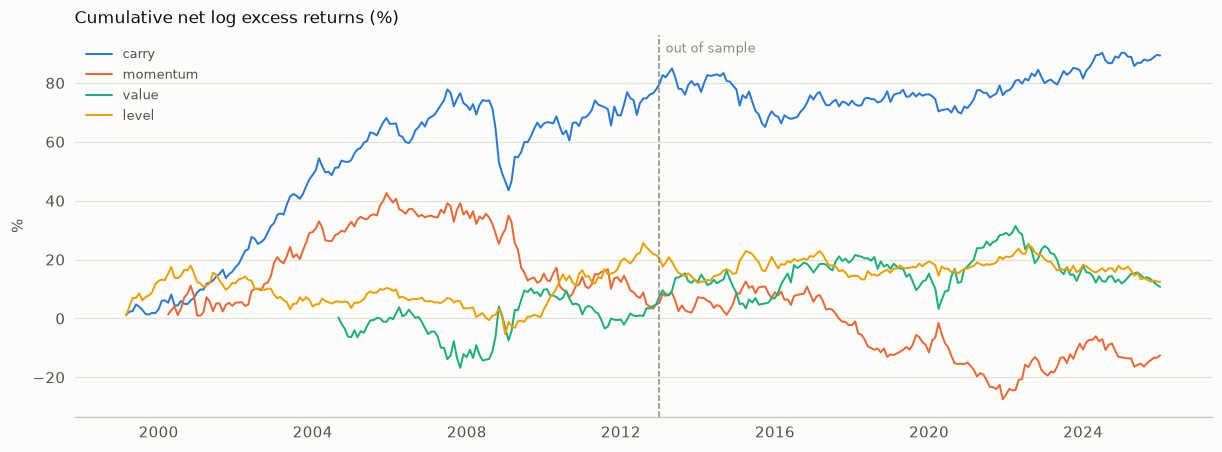

In [3]:
signals = {"carry": fx.carry_signal(rates, CURRENCIES),
           "momentum": fx.momentum_signal(rx, MOM_LOOKBACK, MOM_SKIP),
           "value": fx.value_signal(spot, VALUE_HORIZON)}
weights = {k: fx.cross_sectional_weights(s, N_SIDE, SCHEME) for k, s in signals.items()}
runs = {k: fx.portfolio_returns(w, rx, COST_BP) for k, w in weights.items()}
F = pd.DataFrame({k: r["net"] for k, r in runs.items()})
F["level"] = fx.dollar_factor(rx)
start = F[["carry", "momentum", "value"]].dropna().index[0]
print(f"common sample starts {start:%B %Y} (value needs 5.5 years of history)")

def stats_table(frame, periods):
    rows = {}
    for label, (a, b) in periods.items():
        for k in frame:
            rows[(label, k)] = fx.annualised_stats(frame[k].loc[a:b], NW_LAGS)
    out = pd.DataFrame(rows).T
    out.index.names = ["period", "strategy"]
    return out

PERIODS = {"full sample": (None, END), "1999-2012 (in sample)": (None, IS_END), "2013-2025 (out of sample)": (OOS_START, END)}
display(stats_table(F, PERIODS).round(2))
display(pd.DataFrame({k: r["turnover"].mean() for k, r in runs.items()}, index=["average monthly turnover"]))
print("Correlations (common sample)")
display(F.loc[start:].corr().round(2))

fig, ax = plt.subplots(figsize=(11, 4))
for k in F:
    ax.plot(F.index, 100 * F[k].cumsum(), label=k, lw=1.3)          # a line starts when its signal is available
ax.axvline(pd.Timestamp(OOS_START), color=MUTED, ls="--", lw=1)
ax.annotate("out of sample", (pd.Timestamp(OOS_START), ax.get_ylim()[1]), xytext=(4, -4), textcoords="offset points",
            va="top", fontsize=8.5, color=MUTED)
ax.set(title="Cumulative net log excess returns (%)", ylabel="%")
ax.legend(loc="upper left")
fig.savefig(OUTPUT_DIR / "cumulative_returns.png", dpi=150)

## 3. Crash risk

Carry is known to earn small gains most of the time and to lose sharply when risk appetite collapses (Brunnermeier, Nagel and
Pedersen, 2009). Two diagnostics: the contemporaneous exposure of each style to changes in the VIX and to the level factor,
and the returns in month $t+1$ conditional on the VIX at the end of month $t$. The second is a predictive split, so it can be
traded without look-ahead.

In [4]:
if DATA_MODE == "official":
    vix = data.load_fred(["VIXCLS"])["VIXCLS"].resample("ME").last()
else:
    vix = pd.Series(20 + 5 * np.random.default_rng(SEED).standard_normal(len(rates)), index=rates.index).clip(lower=9)
dvix = vix.diff().reindex(F.index)
rows = {}
for k in ["carry", "momentum", "value"]:
    ok = F[k].notna() & dvix.notna() & F["level"].notna()
    res = fx.newey_west_regression(100 * F[k][ok].to_numpy(), np.column_stack([dvix[ok], 100 * F["level"][ok]]), NW_LAGS)
    rows[k] = {"alpha (% per month)": res["coef"][0], "t alpha": res["t"][0], "beta to VIX change (% per point)": res["coef"][1],
               "t VIX": res["t"][1], "beta to level": res["coef"][2], "t level": res["t"][2], "R2": res["r2"]}
display(pd.DataFrame(rows).T)
print("Worst months of carry (%):", (100 * F["carry"]).nsmallest(6).round(2).to_dict())
high = (vix > VIX_THRESHOLD).shift(1).reindex(F.index).fillna(False).astype(bool)
cond = pd.DataFrame({f"VIX above {VIX_THRESHOLD:g} at the previous month-end": 1200 * F[high].mean(),
                     "otherwise": 1200 * F[~high].mean(),
                     "months above": high.sum()}).T
print("Average return in the following month, % p.a.")
display(cond.round(2))

,alpha (% per month),t alpha,beta to VIX change (% per point),t VIX,beta to level,t level,R2
carry,0.267,2.329,-0.171,-4.821,0.090,0.906,0.162
momentum,-0.041,-0.346,-0.007,-0.166,-0.031,-0.262,0.001
value,0.039,0.310,-0.025,-0.391,0.094,0.612,0.007


Worst months of carry (%): {Timestamp('2008-10-31 00:00:00'): -11.19, Timestamp('2008-09-30 00:00:00'): -6.94, Timestamp('2011-09-30 00:00:00'): -5.56, Timestamp('2015-01-31 00:00:00'): -5.54, Timestamp('2012-05-31 00:00:00'): -5.06, Timestamp('2007-08-31 00:00:00'): -4.59}
Average return in the following month, % p.a.


,carry,momentum,value,level
VIX above 25 at the previous month-end,4.870,-4.140,6.910,0.130
otherwise,2.900,0.450,-0.860,0.550
months above,68.000,68.000,68.000,68.000


## 4. Can risk management reduce the crashes?

Three variants of the carry portfolio, all decided with information up to the end of month $t$:

* **volatility-targeted**: exposure $\sigma^* / \hat\sigma_t$, with $\hat\sigma_t$ the trailing 36-month volatility;
* **variance-managed** (Moreira and Muir, 2017): exposure $c / RV_t$, with $RV_t$ the realised variance of the portfolio's daily
  spot returns during month $t$, capped at 3;
* **VIX filter**: no position in month $t+1$ when the VIX closed month $t$ above 25.

For comparability the variants are rescaled, ex post, to the full-sample volatility of plain carry. The rescaling is a
constant, so it changes no Sharpe ratio, skewness or t-statistic.

In [5]:
carry = F["carry"]
rv = fx.realised_variance(weights["carry"], panel["daily_spot"])
variants = pd.DataFrame({
    "carry": carry,
    "volatility-targeted": fx.volatility_scaled(carry.to_frame(), VOL_WINDOW, TARGET_VOL)["carry"],
    "variance-managed": fx.volatility_managed(carry, rv, target=TARGET_VOL),
    "VIX filter": carry.where(~high, 0.0),
})
variants = variants.loc[variants.dropna().index[0]:]
variants = variants * (variants["carry"].std() / variants.std())
display(stats_table(variants, PERIODS).round(2))

mean (% p.a.)  \
period                    strategy                             
full sample               carry                        2.960   
                          volatility-targeted          3.530   
                          variance-managed             4.120   
                          VIX filter                   2.750   
1999-2012 (in sample)     carry                        5.580   
                          volatility-targeted          6.470   
                          variance-managed             7.700   
                          VIX filter                   5.290   
2013-2025 (out of sample) carry                        0.750   
                          volatility-targeted          1.060   
                          variance-managed             1.120   
                          VIX filter                   0.630   

                                               volatility (% p.a.)  Sharpe  \
period                    strategy                                           
full sample               carry                              7.580   0.390   
                          volatility-targeted                7.580   0.470   
                          variance-managed                   7.580   0.540   
                          VIX filter                         7.580   0.360   
1999-2012 (in sample)     carry                              9.000   0.620   
                          volatility-targeted                8.490   0.760   
                          variance-managed                   7.520   1.020   
                          VIX filter                         8.030   0.660   
2013-2025 (out of sample) carry                              6.110   0.120   
                          volatility-targeted                6.680   0.160   
                          variance-managed                   7.550   0.150   
                          VIX filter                         7.160   0.090   

                                               NW t (mean)  skewness  \
period                    strategy                                     
full sample               carry                      1.760    -0.610   
                          volatility-targeted        2.080    -0.560   
                          variance-managed           2.460    -0.460   
                          VIX filter                 1.830    -0.520   
1999-2012 (in sample)     carry                      1.770    -0.810   
                          volatility-targeted        2.060    -0.770   
                          variance-managed           2.800    -0.640   
                          VIX filter                 2.060    -0.700   
2013-2025 (out of sample) carry                      0.530    -0.360   
                          volatility-targeted        0.700    -0.400   
                          variance-managed           0.630    -0.340   
                          VIX filter                 0.400    -0.390   

                                               worst month (%)  \
period                    strategy                               
full sample               carry                        -11.190   
                          volatility-targeted           -9.420   
                          variance-managed              -7.890   
                          VIX filter                    -8.790   
1999-2012 (in sample)     carry                        -11.190   
                          volatility-targeted           -9.420   
                          variance-managed              -7.890   
                          VIX filter                    -8.790   
2013-2025 (out of sample) carry                         -5.540   
                          volatility-targeted           -5.900   
                          variance-managed              -6.240   
                          VIX filter                    -7.020   

                                               max drawdown (%)  months  
period                    strategy               

## 5. A risk-balanced combination of the three styles

Each style is scaled to 10% volatility with its trailing 36-month volatility (measured up to the previous month) and the
three are averaged. Momentum and value are negatively correlated, which is the classic argument for combining them
(Asness, Moskowitz and Pedersen, 2013). The break-even cost is the cost per unit of turnover that would bring the
net mean return to zero.

In [6]:
scaled = fx.volatility_scaled(F[["carry", "momentum", "value"]], VOL_WINDOW, TARGET_VOL)
combo = scaled.mean(axis=1, skipna=False).dropna().rename("combination")
turnover = sum(runs[k]["turnover"].reindex(combo.index) * (scaled[k] / F[k]).reindex(combo.index).abs() for k in runs) / 3
gross_combo = combo + COST_BP / 1e4 * turnover
breakeven_bp = max(1e4 * gross_combo.mean() / turnover.mean(), 0.0)   # zero when the gross return is already negative
candidates = pd.DataFrame({"carry": F["carry"], "combination": combo}).loc[combo.index[0]:]
print(f"common sample from {combo.index[0]:%B %Y} (value needs 5.5 years of history and the scaling 3 more)")
display(stats_table(candidates, PERIODS).round(2))
print(f"combination: gross mean {1200 * gross_combo.mean():.2f}% p.a., average monthly turnover {turnover.mean():.2f}, "
      f"break-even cost {breakeven_bp:.1f} bp per unit (assumed {COST_BP:g} bp)")
carry_turn = runs["carry"]["turnover"]
breakeven_carry = 1e4 * (F["carry"] + COST_BP / 1e4 * carry_turn).mean() / carry_turn.mean()
print(f"carry: average monthly turnover {carry_turn.mean():.2f}, break-even cost {breakeven_carry:.1f} bp per unit")

common sample from August 2007 (value needs 5.5 years of history and the scaling 3 more)


mean (% p.a.)  volatility (% p.a.)  \
period                    strategy                                          
full sample               carry                0.690                7.920   
                          combination         -0.480                4.980   
1999-2012 (in sample)     carry                0.530               11.190   
                          combination         -1.190                4.730   
2013-2025 (out of sample) carry                0.750                6.110   
                          combination         -0.190                5.100   

                                       Sharpe  NW t (mean)  skewness  \
period                    strategy                                     
full sample               carry         0.090        0.360    -0.530   
                          combination  -0.100       -0.460    -0.370   
1999-2012 (in sample)     carry         0.050        0.100    -0.510   
                          combination  -0.250       -0.650    -0.350   
2013-2025 (out of sample) carry         0.120        0.530    -0.360   
                          combination  -0.040       -0.160    -0.390   

                                       worst month (%)  max drawdown (%)  \
period                    strategy                                         
full sample               carry                -11.190           -28.110   
                          combination           -4.610           -18.560   
1999-2012 (in sample)     carry                -11.190           -28.110   
                          combination           -3.340           -10.980   
2013-2025 (out of sample) carry                 -5.540           -18.050   
                          combination           -4.610           -18.560   

                                       months  
period                    strategy             
full sample               carry       221.000  
                          combination 221.000  
1999-2012 (in sample)     carry        65.000  
                          combination  65.000  
2013-2025 (out of sample) carry       156.000  
                          combination 156.000

combination: gross mean -0.28% p.a., average monthly turnover 0.58, break-even cost 0.0 bp per unit (assumed 3 bp)
carry: average monthly turnover 0.12, break-even cost 234.0 bp per unit


## 6. Robustness and overfitting

The grid combines 3 portfolio sizes (2, 3 or 4 currencies a side) with 2 weighting schemes. Momentum adds 6 look-back
variants and value 2 horizons: 54 configurations in all. We compare in-sample (2005-2012, when every configuration exists)
and out-of-sample Sharpe ratios. We then estimate the probability of backtest overfitting (PBO) by combinatorially
symmetric cross-validation (C++ engine) and compute the deflated Sharpe ratio of the candidates. Their trial count is the
grid plus the three risk-management variants and the combination.

54 configurations; in-sample winner 'value 60m n=2 equal': Sharpe 0.39 in sample, 0.01 out of sample (rank 12 of 54)
correlation between in-sample and out-of-sample Sharpe ratios: -0.12


,in sample,out of sample,share positive out of sample
carry,0.270,0.090,0.830
momentum,-0.170,-0.180,0.030
value,0.190,0.000,0.580


PBO (CSCV, 16 blocks, 2005-2025): 0.34
deflated Sharpe ratios use 58 trials; full-sample returns


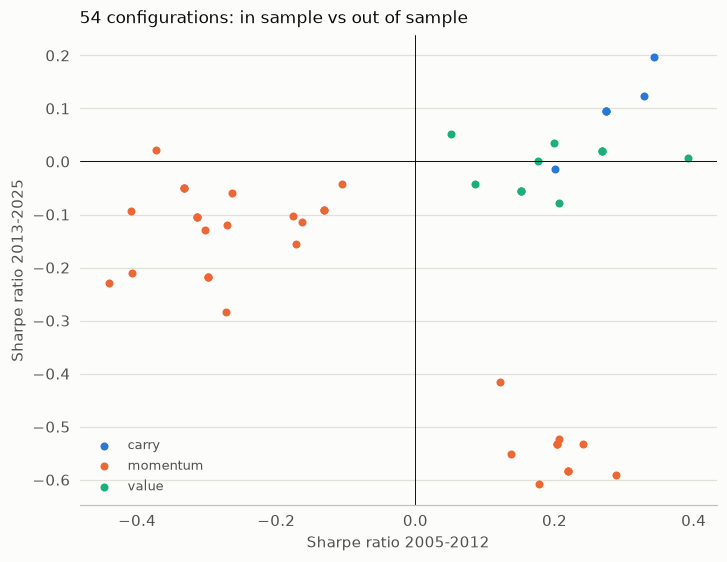

In [7]:
grid = fx.strategy_grid(spot, rates, rx, COST_BP)
IS, OOS = grid.loc["2005":IS_END], grid.loc[OOS_START:END]
sr_is, sr_oos = np.sqrt(12) * IS.mean() / IS.std(), np.sqrt(12) * OOS.mean() / OOS.std()
best = sr_is.idxmax()
print(f"{grid.shape[1]} configurations; in-sample winner '{best}': Sharpe {sr_is[best]:.2f} in sample, {sr_oos[best]:.2f} out of sample "
      f"(rank {int(sr_oos.rank(ascending=False)[best])} of {len(sr_oos)})")
print(f"correlation between in-sample and out-of-sample Sharpe ratios: {np.corrcoef(sr_is, sr_oos)[0, 1]:.2f}")
style = pd.Series([c.split()[0] for c in grid.columns], index=grid.columns)
display(pd.DataFrame({"in sample": sr_is.groupby(style).median(), "out of sample": sr_oos.groupby(style).median(),
                      "share positive out of sample": (sr_oos > 0).groupby(style).mean()}).round(2))
pbo = st.probability_of_backtest_overfitting(grid.loc["2005":].dropna(), S=16)
print(f"PBO (CSCV, 16 blocks, 2005-2025): {pbo['pbo']:.2f}")

fig, ax = plt.subplots(figsize=(6.5, 5))
for s_, c_ in zip(["carry", "momentum", "value"], SERIES):
    m = style == s_
    ax.scatter(sr_is[m], sr_oos[m], s=18, color=c_, label=s_)
ax.axhline(0, color="k", lw=0.6)
ax.axvline(0, color="k", lw=0.6)
ax.set(xlabel="Sharpe ratio 2005-2012", ylabel="Sharpe ratio 2013-2025", title="54 configurations: in sample vs out of sample")
ax.legend(loc="lower left")
fig.savefig(OUTPUT_DIR / "grid_is_oos.png", dpi=150)

n_trials = grid.shape[1] + 3 + 1
trial_sharpes = np.r_[(grid.mean() / grid.std()).to_numpy(), (variants.mean() / variants.std()).to_numpy()[1:],
                      combo.mean() / combo.std()]
decision_rows = {}
for name, series in {"carry": F["carry"], "combination": combo}.items():
    oos = series.loc[OOS_START:END].dropna()
    boot = mt.bootstrap_sharpe(oos.to_numpy(), mean_block=6, n_boot=10_000, seed=SEED, periods_per_year=12)
    dsr = mt.deflated_sharpe_ratio(series.dropna().to_numpy(), trial_sharpes)
    cum = oos.cumsum()
    be = breakeven_carry if name == "carry" else breakeven_bp
    decision_rows[name] = {"Sharpe ratio 2013-2025 (net)": np.sqrt(12) * oos.mean() / oos.std(),
                           "Bootstrap 95% lower bound of the 2013-2025 Sharpe ratio": float(np.quantile(boot, 0.025)),
                           "Deflated Sharpe ratio (all configurations tried)": dsr["dsr"],
                           "Maximum drawdown 2013-2025": float(np.exp((cum - cum.cummax()).min()) - 1),
                           "Break-even cost / assumed cost": be / COST_BP}
print(f"deflated Sharpe ratios use {n_trials} trials; full-sample returns")

## 7. Decision

The criteria were fixed before the analysis (see the set-up cell). A candidate is approved only if it meets all of them.

In [8]:
rows = {}
for criterion, (op, threshold) in CRITERIA.items():
    row = {"threshold": f"{op} {threshold:g}"}
    for name, values in decision_rows.items():
        v = values[criterion]
        ok = v >= threshold if op == ">=" else v > threshold
        row[name] = f"{v:.2f} {'pass' if ok else 'FAIL'}"
    rows[criterion] = row
decision = pd.DataFrame(rows).T
display(decision)
for name in decision_rows:
    verdict = "GO" if decision[name].str.endswith("pass").all() else "NO-GO"
    print(f"{name}: {verdict}")

,threshold,carry,combination
Sharpe ratio 2013-2025 (net),>= 0.5,0.12 FAIL,-0.04 FAIL
Bootstrap 95% lower bound of the 2013-2025 Sharpe ratio,> 0,-0.33 FAIL,-0.51 FAIL
Deflated Sharpe ratio (all configurations tried),>= 0.95,0.54 FAIL,0.01 FAIL
Maximum drawdown 2013-2025,>= -0.2,-0.18 pass,-0.19 pass
Break-even cost / assumed cost,>= 3,78.00 pass,0.00 FAIL


carry: NO-GO
combination: NO-GO


## 8. Conclusions

Results on official data, February 1999 - December 2025, net of 3 bp per unit of turnover (in synthetic mode the numbers
differ).

- **Uncovered interest parity cannot be rejected, but it cannot be confirmed either.** The pooled Fama slope is 0.20 with a
  standard error of 0.71 (95% interval -1.2 to 1.6). Twenty-seven years of G10 data against the euro are too noisy to settle
  the forward premium puzzle, which is a first warning about how strong any carry evidence can be.
- **Carry** earned 3.3% a year with 7.3% volatility (Sharpe ratio 0.45, Newey-West t 2.2), but 5.7% a year before 2013 and only
  0.75% since (Sharpe 0.12, t 0.5). It is a crash-prone strategy: skewness -0.65, worst month -11.2% (October 2008), drawdown
  29%, and it loses 0.17% for each point of rise in the VIX (t -4.8). Its alpha after the VIX and the level factor is still
  0.27% a month (t 2.3) over the full sample, which is consistent with compensation for crash risk.
- **Momentum** lost money (-0.5% a year; -1.4% since 2013) and trades heavily (turnover 0.8 a month). **Value**, a nominal
  5-year reversal proxy, earned 0.5% a year with no significance; its -0.55 correlation with momentum is the only feature
  that matches the literature.
- **Risk management did not survive out of sample.** At equal volatility, the variance-managed carry raises the in-sample
  Sharpe ratio from 0.62 to 1.02 and halves the drawdown. After 2012 it barely changes (0.15 against 0.12) and its worst month
  is slightly worse. A VIX filter is counterproductive: after month-ends with the VIX above 25, carry earned 4.9% a year in the
  following month against 2.9% otherwise, so stepping aside forgoes the rebound that pays for the crash.
- **The risk-balanced combination** loses 0.3% a year before costs from August 2007, because momentum's losses offset
  carry. Costs are not the problem: carry breaks even only at 234 bp per unit of turnover.
- **Overfitting.** Across the 54 configurations the in-sample and out-of-sample Sharpe ratios are uncorrelated (-0.12). The
  in-sample winner (value, 2 currencies a side) falls from 0.39 to 0.01, and the PBO is 0.34. Carry is the only robust style:
  83% of its configurations are positive after 2012, but with a median Sharpe ratio of only 0.09.
- **Decision: no-go for both candidates.** Carry fails the Sharpe (0.12 against 0.50), bootstrap (lower bound -0.33) and
  deflated Sharpe (0.54) criteria; the combination fails all five.

**What would change the conclusion:** a broader universe (emerging-market currencies, where carry premia are larger and
better documented), a real-exchange-rate value signal built from national consumer price indices, and forward points
instead of monthly-average interbank rates. A carry allocation could be reconsidered as a deliberate, sized exposure to crash
risk rather than as an alpha source.

**Limitations.** Nine currencies only; monthly-average 3-month rates approximate one-month forward discounts; spot fixings are
ECB reference rates (14:15 CET), not tradable closes; no financing spreads or margin costs; the VIX is a US equity volatility
index used as a proxy for global risk appetite.